
# $h_k(t)$ exacto (semi-analítico) — potencial isócrono

Calcula los modos de Fourier de mezcla de fase $h_k(t)$ de forma **exacta**
(cuadratura numérica de alta resolución sobre las variables ángulo-acción,
sin partículas ni ruido de discretización), para compararlos contra los
$h_k(t)$ que salen de una corrida real de `vlasov-poisson_PIC`/
`VlasovPoisson_PIC_sp`.

**Motivación**: en las corridas PIC (tanto reconstruidas como los datos
originales del artículo), $h_k$ para $k>0$ no decae hasta el piso de ruido
que predice la teoría — se estabiliza varios órdenes de magnitud por
arriba de lo esperado. Este notebook calcula la referencia "verdadera"
(sin ese artefacto) para poder cuantificar la brecha con precisión, en vez
de compararla a ojo.

## Ecuaciones (ver `main.md`, Secc. 3-4, y `BUGS_TODO.md`/
`h0_normalization_check.md` de esta sesión)

Con el potencial isócrono adimensional ($G=M_{iso}=m=b=1$) y momento
angular fijo $L_0$, la frecuencia radial es
$$\omega(J) = \frac{1}{\left[J+\tfrac12\left(L_0+\sqrt{L_0^2+4}\right)\right]^3}.$$

La distribución inicial (Ec. DF$_{aa}$ del artículo) es un pulso en
variables ángulo-acción:
$$\mathcal F_0(Q,J) = A_0\, e^{-\sin^2(Q/2)/\sigma_Q^2}\, e^{-(J-J_0)^2/\sigma_J^2}\, J^2,$$
y su coeficiente de Fourier en $Q$ (a $J$ fijo) es
$$\hat{\mathcal F}_k(J) = \frac{1}{2\pi}\int_0^{2\pi} \mathcal F_0(Q,J)\, e^{-ikQ}\, dQ
= A_0\, e^{-(J-J_0)^2/\sigma_J^2} J^2 \cdot \underbrace{\frac{1}{2\pi}\int_0^{2\pi} e^{-\sin^2(Q/2)/\sigma_Q^2}\cos(kQ)\, dQ}_{\text{mismo para } \Phi}.$$

(La parte imaginaria se cancela por simetría — $\mathrm{Re}$ es par y
$\mathrm{Im}$ impar respecto a $Q=\pi$ — así que no hace falta calcularla.)

La función de prueba $\Phi$ tiene la misma forma con $A_0=1$ y sus propios
parámetros $(J_0^\Phi,\sigma_Q^\Phi,\sigma_J^\Phi)$. El modo de mezcla,
**Ec. 44 del artículo** (reducida vía $\mathcal F(r,p_r,L)=\mathcal
F_0(r,p_r)\,\delta(L-L_0)$, ver la derivación completa en
`h0_normalization_check.md` §3 y §9-10 de esta sesión), es
$$h_k(t) = 8\pi^2 L_0 \cdot 2\pi \int_0^\infty \hat{\mathcal F}_k(J)\,
\hat\Phi_k(J)^*\, e^{-ik\,\omega(J)\,t}\, dJ.$$

El factor $8\pi^2 L_0$ es exactamente el que faltaba en el código
Fortran (`analysish.f90`) y que agregamos esta sesión — acá se incluye
desde el principio.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110


/home/erik/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "



## 1. Parámetros físicos

Los valores por defecto reproducen el test de validación del artículo
(Tabla 1/2, Fig. 3): $L_0=2$, $\sigma_Q=\sigma_J=0.1$, $J_3^{(0)}=0$,
masa $a_0 = 10^{-4}\,M_{iso}$.

La función de prueba $\Phi$ por defecto es igual a $\mathcal F_0$ (con
$A_0=1$) — el caso que usa la Tabla 1. Para reproducir el caso con
$\Phi_2$ de la Tabla 3, cambiá `J0_phi`, `sQ_phi`, `sJ_phi` más abajo.


In [2]:

# --- Distribucion inicial F0 (Ec. DF_aa) ---
L0   = 2.0     # momento angular fijo
J0_F = 0.0     # J3^(0)
sQ_F = 0.1     # sigma_Q
sJ_F = 0.1     # sigma_J
a0_target = 1.0e-4   # masa objetivo, en unidades de M_iso

# --- Funcion de prueba Phi (por defecto: igual a F0, A0=1) ---
J0_phi = 0.0
sQ_phi = 0.1
sJ_phi = 0.1

# --- Resolucion de las cuadraturas ---
nQ   = 4000     # subintervalos de Simpson en Q, sobre [0,2pi]
Jmax = 3.0      # dominio de integracion en J: [0, Jmax]
nJ   = 8000     # subintervalos de Simpson en J

modes = [0, 1, 2, 3, 4]   # que k's calcular



## 2. Funciones auxiliares

Cuadratura de Simpson manual (no usa `scipy.integrate` — evita
problemas de compatibilidad de versión numpy/scipy en algunos entornos;
con `nQ`/`nJ` de varios miles la precisión es más que suficiente).


In [3]:

def simpson(y, x):
    '''Cuadratura de Simpson compuesta, x uniforme, len(x) impar (n par).'''
    n = len(x) - 1
    assert n % 2 == 0, "se necesita un numero par de subintervalos"
    h = (x[-1] - x[0]) / n
    return (y[0] + y[-1] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-2:2])) * h / 3.0


def omega(J, L=L0):
    '''Frecuencia radial del potencial isocrono adimensional.'''
    return 1.0 / (J + 0.5*(L + np.sqrt(L**2 + 4.0)))**3


def Fhat_k_over_A0(Js, k, J0, sQ, sJ):
    '''Coeficiente de Fourier en Q (real), con amplitud A0=1:
    (1/2pi) * Simpson[ exp(-sin(Q/2)^2/sQ^2) * cos(kQ) dQ, 0..2pi ]
    * exp(-(J-J0)^2/sJ^2) * J^2 , evaluado en el arreglo Js.
    '''
    Qs = np.linspace(0.0, 2*np.pi, nQ + 1)
    g = np.exp(-np.sin(0.5*Qs)**2 / sQ**2)
    Qint = simpson(g * np.cos(k*Qs), Qs) / (2*np.pi)
    return Qint * np.exp(-(Js - J0)**2 / sJ**2) * Js**2



## 3. Normalización de masa

$a_0$ (fracción de $M_{iso}$) fija $A_0$ vía
$M_{gas} = 8\pi^2 L_0 \int\!\!\int \mathcal F_0(Q,J)\, dQ\, dJ
= 8\pi^2 L_0 \cdot 2\pi \int \hat{\mathcal F}_0(J)\, dJ$
(con $k=0$: la integral en $Q$ da el promedio angular).


In [4]:

Js_mass = np.linspace(0.0, Jmax, nJ + 1)
IJ0 = simpson(Fhat_k_over_A0(Js_mass, 0, J0_F, sQ_F, sJ_F), Js_mass)
mass_per_A0 = 8*np.pi**2 * L0 * 2*np.pi * IJ0

A0 = a0_target / mass_per_A0
print(f"masa por unidad de A0 = {mass_per_A0:.6e}")
print(f"A0 (para masa = {a0_target:g} M_iso) = {A0:.6e}")


masa por unidad de A0 = 2.486775e-02
A0 (para masa = 0.0001 M_iso) = 4.021273e-03



## 4. Cálculo de $h_k(t)$

$$h_k(t) = 8\pi^2 L_0 \cdot 2\pi \cdot A_0 \int_0^{J_{max}}
\hat{\mathcal F}_k^{(A_0=1)}(J)\, \hat\Phi_k(J)\, e^{-ik\,\omega(J)\,t}\, dJ$$

($\hat\Phi_k$ ya tiene $A_0=1$ por definición de función de prueba.)


In [5]:

Js = np.linspace(0.0, Jmax, nJ + 1)
om = omega(Js)

FACTOR = 8*np.pi**2 * L0 * 2*np.pi * A0

# Fhat_k y Phihat_k no dependen de t: calcularlos una sola vez por modo.
Fhat  = {k: Fhat_k_over_A0(Js, k, J0_F,   sQ_F,   sJ_F)   for k in modes}
Phhat = {k: Fhat_k_over_A0(Js, k, J0_phi, sQ_phi, sJ_phi) for k in modes}

def hk_exact(k, t):
    '''h_k(t) exacto (complejo). t puede ser escalar o arreglo.'''
    t = np.atleast_1d(t).astype(float)
    out = np.empty(t.shape, dtype=complex)
    for i, ti in enumerate(t):
        integrand = Fhat[k] * Phhat[k] * np.exp(-1j*k*om*ti)
        re = simpson(integrand.real, Js)
        im = simpson(integrand.imag, Js)
        out[i] = FACTOR * (re + 1j*im)
    return out if out.size > 1 else out[0]



## 5. Evaluar en una grilla de tiempo y graficar cada modo


In [6]:

t_array = np.linspace(0.0, 10000.0, 400)

hk_t = {k: np.abs(hk_exact(k, t_array)) for k in modes}

print(f"h_0 (constante en t, teoria de mezcla): {hk_t[0][0]:.6e}")
for k in modes[1:]:
    print(f"h_{k}(t=0) = {hk_t[k][0]:.3e}   h_{k}(t=10000) = {hk_t[k][-1]:.3e}")


h_0 (constante en t, teoria de mezcla): 1.499817e-08
h_1(t=0) = 1.470e-08   h_1(t=10000) = 5.631e-16
h_2(t=0) = 1.383e-08   h_2(t=10000) = 1.648e-17
h_3(t=0) = 1.251e-08   h_3(t=10000) = 1.971e-18
h_4(t=0) = 1.086e-08   h_4(t=10000) = 4.303e-19


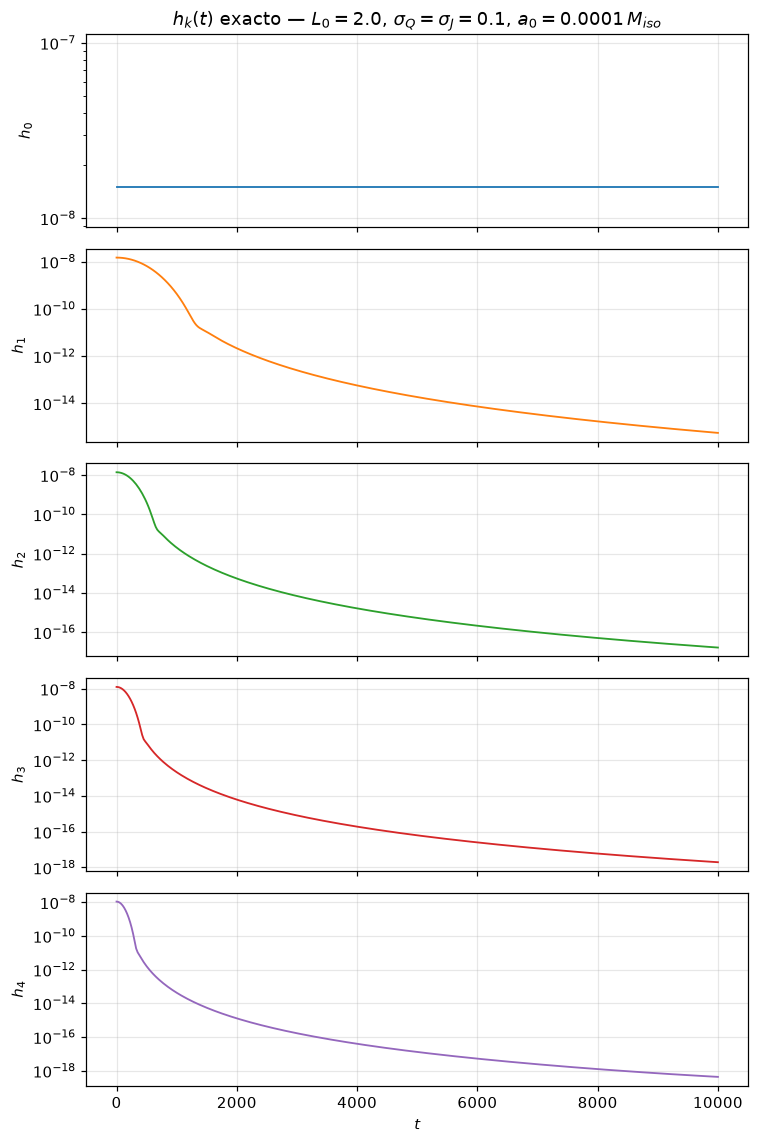

In [7]:

fig, axes = plt.subplots(len(modes), 1, figsize=(7, 2.1*len(modes)), sharex=True)
for ax, k in zip(axes, modes):
    ax.plot(t_array, hk_t[k], lw=1.2, color=f"C{k}")
    ax.set_yscale("log")
    ax.set_ylabel(f"$h_{k}$")
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("$t$")
axes[0].set_title(f"$h_k(t)$ exacto — $L_0={L0}$, $\\sigma_Q=\\sigma_J={sQ_F}$, $a_0={a0_target:g}\\,M_{{iso}}$")
fig.tight_layout()
fig.savefig("hk_exact_modes.png", dpi=140)
plt.show()


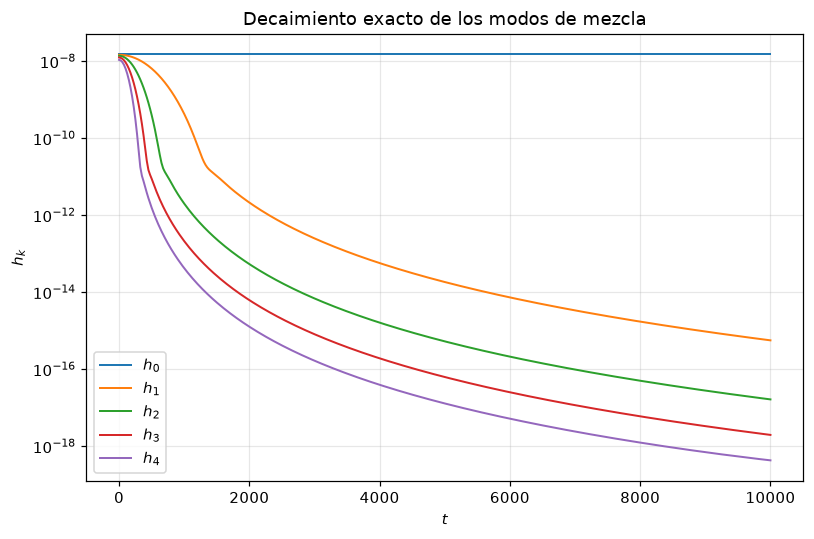

In [8]:

# Mismos datos, superpuestos en un solo eje (estilo Fig. 3 del articulo)
fig, ax = plt.subplots(figsize=(7.5, 5))
for k in modes:
    ax.plot(t_array, hk_t[k], lw=1.3, label=f"$h_{k}$")
ax.set_yscale("log")
ax.set_xlabel("$t$")
ax.set_ylabel("$h_k$")
ax.set_title("Decaimiento exacto de los modos de mezcla")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("hk_exact_overlay.png", dpi=140)
plt.show()



---
# 6. Cómo se ve el phase mixing

Cada partícula orbita con su propia frecuencia $\omega(J)=1/(J+c)^3$, así
que una nube inicialmente compacta en ángulo se estira y se enrolla en
espiral. Color = $J_3$ **inicial** de cada partícula, para poder seguir
de dónde viene.


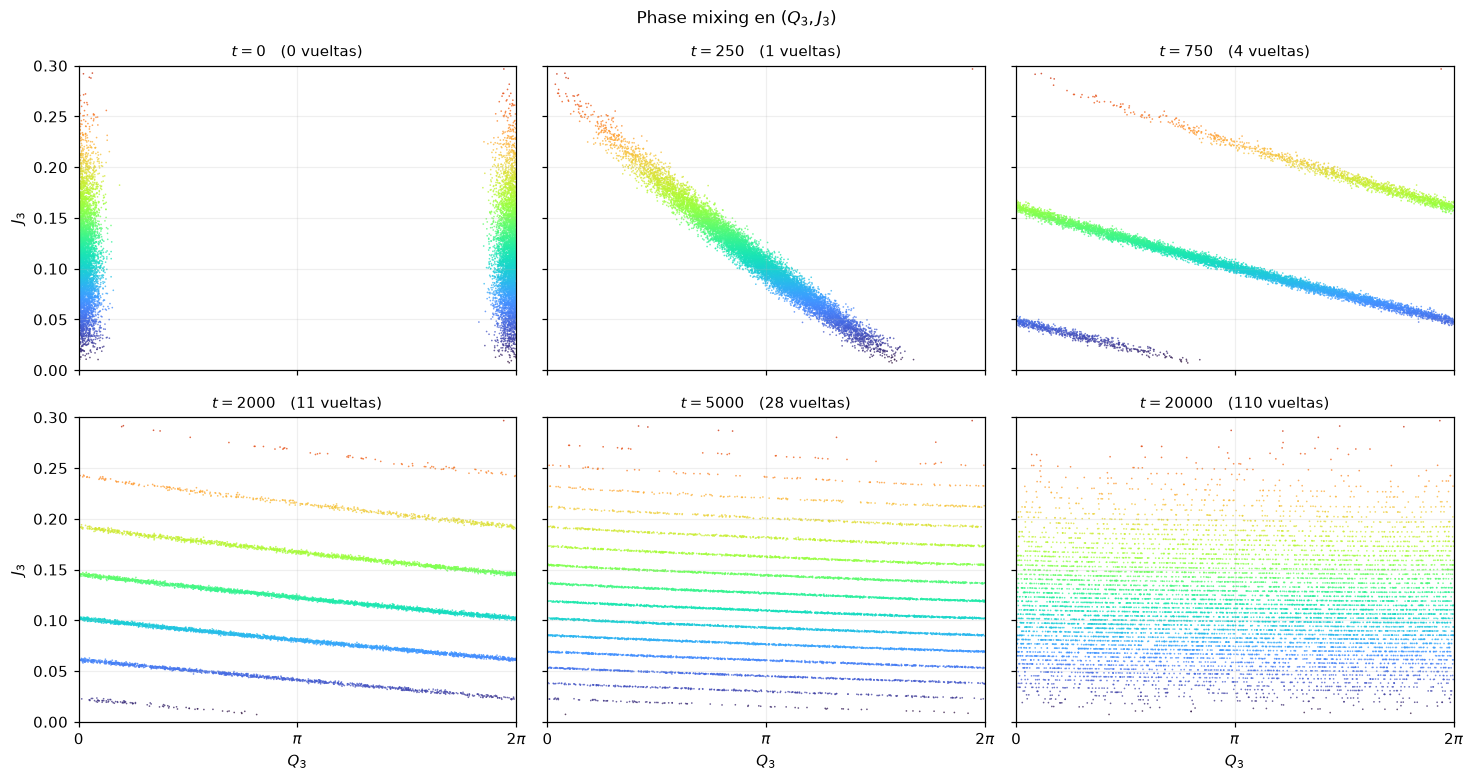

In [9]:

import os
data_dir = "data"
tiempos = [0, 250, 750, 2000, 5000, 20000]
qj = {t: np.genfromtxt(os.path.join(data_dir, f"qj_t{t}.tl")) for t in tiempos}
col = qj[0][:, 1]            # J inicial, fijo como color

fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.2), sharex=True, sharey=True)
for ax, t in zip(axes.ravel(), tiempos):
    ax.scatter(qj[t][:,0], qj[t][:,1], c=col, s=1.2, cmap="turbo", alpha=.75, linewidths=0)
    ax.set_title(f"$t={t}$   ({t*5.507e-3:.0f} vueltas)", fontsize=10)
    ax.set_ylim(0, 0.30); ax.set_xlim(0, 2*np.pi)
    ax.set_xticks([0, np.pi, 2*np.pi]); ax.set_xticklabels(["0","$\\pi$","$2\\pi$"])
    ax.grid(alpha=.2)
for ax in axes[:,0]: ax.set_ylabel("$J_3$")
for ax in axes[-1,:]: ax.set_xlabel("$Q_3$")
fig.suptitle("Phase mixing en $(Q_3,J_3)$", fontsize=11)
fig.tight_layout(); fig.savefig("phase_mixing_QJ.png", dpi=140); plt.show()


In [10]:

c_iso = 0.5*(L0 + np.sqrt(L0**2 + 4.0))
Jtyp  = np.median(qj[0][:,1])
om_t  = 1.0/(Jtyp + c_iso)**3
dom   = 3.0/(Jtyp + c_iso)**4
print(f"J tipico = {Jtyp:.4f},  periodo orbital = {2*np.pi/om_t:.1f},  |domega/dJ| = {dom:.4f}")
print(f"dos particulas con dJ=0.1 se desfasan una vuelta en t = {2*np.pi/(dom*0.1):.0f}")
print()
print("ancho de franja de la espiral (comparar con sigma_J = 0.1):")
for t in tiempos[1:]:
    print(f"  t={t:6d}:  dJ_franja = {2*np.pi/(dom*t):.2e}")


J tipico = 0.1089,  periodo orbital = 100.9,  |domega/dJ| = 0.0740
dos particulas con dJ=0.1 se desfasan una vuelta en t = 849

ancho de franja de la espiral (comparar con sigma_J = 0.1):
  t=   250:  dJ_franja = 3.40e-01
  t=   750:  dJ_franja = 1.13e-01
  t=  2000:  dJ_franja = 4.24e-02
  t=  5000:  dJ_franja = 1.70e-02
  t= 20000:  dJ_franja = 4.24e-03



El ancho de franja se achica como $1/t$. **Resolverlo es exactamente la
condición de Nyquist** $N_J\gtrsim4k\Delta\omega t/2\pi$ que aparece en la
Sec. 7: cuando la espiral se vuelve más fina que la separación entre
partículas, el método deja de seguirla.

Vale subrayar un punto conceptual: *phase mixing no es disipación*. $F$ se
conserva exactamente a lo largo de las trayectorias; lo que decae es solo
la proyección sobre funciones de prueba suaves. Por eso $h_k$ cae mientras
la estructura fina se hace **más** rica, no menos.



---
# 7. Calibración: cuatro esquemas, cuatro décadas de $N$

Todas con `yoshida4`, $\epsilon=0$ y courant=1.0 — elegido para que el
**integrador no sea el limitante** (su error a ese $\Delta t$ es 8.7e-20).
Partículas **supervivientes** igualadas entre esquemas, no nominales.


In [11]:

Ncal = {'aa_e1':100,'aa_e2':1001,'aa_e3':10020,'aa_e4':100186,
        'aa_halton_e1':98,'aa_halton_e2':1009,'aa_halton_e3':10007,'aa_halton_e4':100185,
        'rand_e1':100,'rand_e2':1024,'rand_e3':10000,'rand_e4':99856,
        'quad_e2':1000,'quad_e3':10000,'quad_e4':100000}
esquemas = {'aa (rejilla $r,p$)'        : ['aa_e1','aa_e2','aa_e3','aa_e4'],
            'aa_halton'                 : ['aa_halton_e1','aa_halton_e2','aa_halton_e3','aa_halton_e4'],
            'aa_random (MC)'            : ['rand_e1','rand_e2','rand_e3','rand_e4'],
            'aa_quad (cuadratura $Q,J$)': ['quad_e2','quad_e3','quad_e4']}
cal = {k: np.genfromtxt(os.path.join(data_dir, f"cal_{k}.tl")) for k in Ncal}

for t in [500., 3000.]:
    ex = abs(hk_exact(1, t))
    print(f"\n=== t={t:.0f}   |h_1| exacto = {ex:.4e}   (error relativo) ===")
    print(f"{'esquema':>28}" + "".join(f"{'N='+str(n):>12}" for n in [100,1000,10000,100000]))
    for nombre, tags in esquemas.items():
        fila = f"{nombre:>28}"
        for n in [100,1000,10000,100000]:
            tg = [k for k in tags if abs(np.log10(Ncal[k]/n)) < 0.2]
            if not tg: fila += f"{'--':>12}"; continue
            d = cal[tg[0]]; v = d[np.argmin(abs(d[:,0]-t)), 2]
            fila += f"{abs(v-ex)/ex:12.2e}"
        print(fila)



=== t=500   |h_1| exacto = 6.4730e-09   (error relativo) ===
                     esquema       N=100      N=1000     N=10000    N=100000
          aa (rejilla $r,p$)    7.54e-03    7.38e-03    7.48e-03    7.54e-03
                   aa_halton    2.97e-02    8.66e-03    7.43e-03    7.54e-03
              aa_random (MC)    1.66e-01    2.42e-02    2.89e-02    7.33e-03
  aa_quad (cuadratura $Q,J$)          --    7.76e-05    1.29e-07    1.18e-07

=== t=3000   |h_1| exacto = 2.5069e-13   (error relativo) ===
                     esquema       N=100      N=1000     N=10000    N=100000
          aa (rejilla $r,p$)    2.03e+04    1.44e+00    8.53e-02    3.44e-02
                   aa_halton    2.87e+03    3.30e+02    6.13e+01    2.95e-01
              aa_random (MC)    7.70e+03    5.29e+02    4.70e+02    1.55e+02
  aa_quad (cuadratura $Q,J$)          --    2.75e+04    9.98e-06    4.70e-07


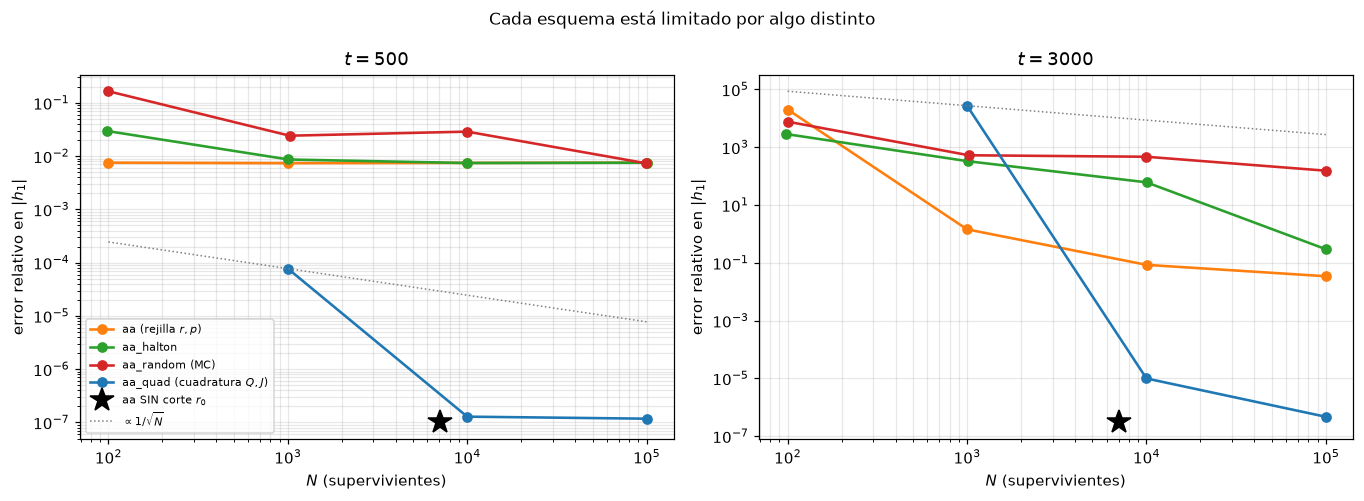

In [12]:

cols_e = {'aa (rejilla $r,p$)':'tab:orange','aa_halton':'tab:green',
          'aa_random (MC)':'tab:red','aa_quad (cuadratura $Q,J$)':'tab:blue'}
nocut = np.genfromtxt(os.path.join(data_dir, "cal_aa_nocut.tl"))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
for ax, t in zip(axes, [500., 3000.]):
    ex = abs(hk_exact(1, t))
    for nombre, tags in esquemas.items():
        Ns, es = [], []
        for tg in tags:
            d = cal[tg]; v = d[np.argmin(abs(d[:,0]-t)), 2]
            Ns.append(Ncal[tg]); es.append(abs(v-ex)/ex)
        ax.loglog(Ns, es, 'o-', color=cols_e[nombre], lw=1.7, ms=6, label=nombre)
    v = nocut[np.argmin(abs(nocut[:,0]-t)), 2]
    ax.loglog([7025], [abs(v-ex)/ex], '*', color='k', ms=16, label='aa SIN corte $r_0$')
    Nr = np.array([1e2, 1e5])
    ax.loglog(Nr, es[0]*(Nr/Ns[0])**-0.5, ':', color='0.5', lw=1,
              label='$\\propto1/\\sqrt{N}$' if t == 500 else None)
    ax.set_xlabel("$N$ (supervivientes)"); ax.set_ylabel("error relativo en $|h_1|$")
    ax.set_title(f"$t={t:.0f}$"); ax.grid(alpha=.3, which='both')
axes[0].legend(fontsize=7.5, loc='lower left')
fig.suptitle("Cada esquema está limitado por algo distinto", fontsize=11)
fig.tight_layout(); fig.savefig("calibracion.png", dpi=140); plt.show()



**Tres comportamientos cualitativamente distintos:**

- **`aa_random`**: ley de potencias limpia, $\propto1/\sqrt N$. Pero es
  inservible a tiempos tardíos: a $N=10^5$ sigue 155× fuera en $t=3000$.
- **`aa_quad`**: **no** es ley de potencias sino un **umbral de Nyquist**.
  Basura a $N=10^3$ ($N_J=25$, por debajo de los ~66 requeridos a
  $t=3000$) y un salto de **nueve órdenes** a $N=10^4$.
- **`aa`/`aa_halton`**: no mejoran con $N$ — ver la sección siguiente.



---
# 8. El corte `r0`: un sistemático que $N$ no arregla

`aa` da 7.54e-3, 7.38e-3, 7.48e-3, 7.54e-3 a $t=500$ sobre **tres décadas
de $N$**. Eso no es ruido: es un sistemático. El culpable es el corte
`r0`=0.01, que descarta el 98% de los nodos de la rejilla y por lo tanto
**trunca la regla de cuadratura**; a $t$ grande la integral sobrevive solo
por cancelación casi total, así que truncar las colas al 1% domina.

Prueba controlada: mismo $N$ superviviente, solo cambia el corte.


In [13]:

cut = cal['aa_e3']    # r0=0.01, N=10020
print(f"{'t':>6} {'exacto':>12} | {'r0=0.01 (N=10020)':>19} {'err.rel':>9} | {'r0=1e-9 (N=7025)':>18} {'err.rel':>9}")
for t in [500., 1000., 1500., 3000.]:
    ex = abs(hk_exact(1, t))
    a = cut[np.argmin(abs(cut[:,0]-t)), 2]
    b = nocut[np.argmin(abs(nocut[:,0]-t)), 2]
    print(f"{t:6.0f} {ex:12.3e} | {a:19.3e} {abs(a-ex)/ex:9.2e} | {b:18.3e} {abs(b-ex)/ex:9.2e}")


     t       exacto |   r0=0.01 (N=10020)   err.rel |   r0=1e-9 (N=7025)   err.rel
   500    6.473e-09 |           6.521e-09  7.48e-03 |          6.473e-09  1.02e-07
  1000    4.301e-10 |           4.340e-10  9.22e-03 |          4.301e-10  1.02e-07
  1500    1.052e-11 |           1.059e-11  6.51e-03 |          1.052e-11  1.18e-07
  3000    2.507e-13 |           2.721e-13  8.53e-02 |          2.507e-13  3.11e-07



Con **menos** partículas (7025 vs 10020), **cinco órdenes menos de error**.

Esto corrige una atribución previa: el piso del baseline `aa` se había
adjudicado al *layout* (espaciado irregular en $J$ de una rejilla uniforme
en $(r,p)$). Era el corte. Sin corte, la rejilla $(r,p)$ llega a 3.1e-7 con
7025 partículas — comparable a `aa_quad` con $10^5$. La rejilla en $(r,p)$
es perfectamente buena como cuadratura; **descartar nodos es lo que la
arruinaba**.

Consecuencia práctica: si se usa `aa`, **bajar `r0`** es el cambio de un
solo número que más precisión compra.



---
# 9. Integradores: orden verificado y costo

Referencia = corrida con `integrator="analytic"` (avance exacto en forma
cerrada). Comparte partículas, rejilla, cuadratura y `analysish` con las
demás, así que la diferencia aísla **solo** el error del integrador.


In [14]:

ref_o2 = np.genfromtxt(os.path.join(data_dir, "o2_analytic_c8.0.tl"))
vref   = ref_o2[np.argmin(abs(ref_o2[:,0]-3000.)), 2]
print(f"referencia 'analytic': h_1(t=3000) = {vref:.16e}\n")
for integ, cs in [("leapfrog",['1.0','2.0','4.0']),
                  ("yoshida4",['1.0','2.0','4.0','8.0']),
                  ("yoshida6",['2.0','4.0','8.0'])]:
    print(f"--- {integ} ---")
    print(f"{'dt':>6} {'error abs':>13} {'razon':>8} {'orden p':>8}")
    prev = None
    for c in cs:
        d = np.genfromtxt(os.path.join(data_dir, f"o2_{integ}_c{c}.tl"))
        v = d[np.argmin(abs(d[:,0]-3000.)), 2]; e = abs(v-vref)
        if prev: print(f"{float(c)*0.05:6.2f} {e:13.3e} {e/prev:7.2f}x {np.log2(e/prev):8.2f}")
        else:    print(f"{float(c)*0.05:6.2f} {e:13.3e} {'--':>8} {'--':>8}")
        prev = e
    print()


referencia 'analytic': h_1(t=3000) = 2.5069238690563810e-13

--- leapfrog ---
    dt     error abs    razon  orden p
  0.05     1.946e-15       --       --
  0.10     8.033e-15    4.13x     2.05
  0.20     3.568e-14    4.44x     2.15

--- yoshida4 ---
    dt     error abs    razon  orden p
  0.05     8.696e-20       --       --
  0.10     1.408e-18   16.19x     4.02
  0.20     2.252e-17   15.99x     4.00
  0.40     3.595e-16   15.96x     4.00

--- yoshida6 ---
    dt     error abs    razon  orden p
  0.10     1.269e-21       --       --
  0.20     6.069e-22    0.48x    -1.06
  0.40     7.311e-20  120.46x     6.91




`leapfrog` da $p\approx2.1$ y **`yoshida4` da 4.02, 4.00, 4.00** — tres
razones consecutivas de 16.00 sobre tres décadas, que confirman el cuarto
orden y de paso validan sus coeficientes.

`yoshida6` es evidencia **más débil**: solo un intervalo utilizable
($p=6.91$); por debajo de $\Delta t=0.2$ su error ya está en ~1e-21 y choca
contra un piso no identificado. Es de orden alto ($\geq$6), pero sin la
solidez del 4.00 repetido.

**Y no hace falta sexto orden**: `yoshida4` a $\Delta t=0.05$ da 8.7e-20,
muy por debajo de $h_4^{exacto}=4.3\times10^{-19}$ a $t=10^4$. Los modos
altos ya se resuelven con cuarto orden, a 3 evaluaciones de fuerza por
paso en vez de 7.


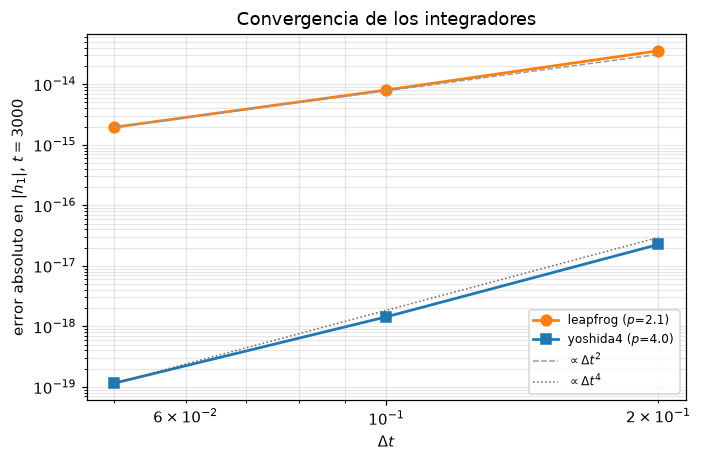

In [15]:

ex3 = abs(hk_exact(1, 3000.))
dts = np.array([0.05, 0.10, 0.20]); cs3 = ['1.0','2.0','4.0']
err = {}
for integ in ['leapfrog','yoshida4']:
    err[integ] = np.array([abs(np.genfromtxt(os.path.join(data_dir, f"bm_{integ}_c{c}.tl"))
                               [np.argmin(abs(np.genfromtxt(os.path.join(data_dir, f"bm_{integ}_c{c}.tl"))[:,0]-3000.)), 2] - ex3)
                           for c in cs3])
fig, ax = plt.subplots(figsize=(6.5, 4.3))
ax.loglog(dts, err['leapfrog'], 'o-', color="tab:orange", lw=1.8, ms=7, label="leapfrog ($p$=2.1)")
ax.loglog(dts, err['yoshida4'], 's-', color="tab:blue",   lw=1.8, ms=7, label="yoshida4 ($p$=4.0)")
ax.loglog(dts, err['leapfrog'][0]*(dts/dts[0])**2, '--', color="0.6", lw=1, label="$\\propto\\Delta t^2$")
ax.loglog(dts, err['yoshida4'][0]*(dts/dts[0])**4, ':',  color="0.4", lw=1, label="$\\propto\\Delta t^4$")
ax.set_xlabel("$\\Delta t$"); ax.set_ylabel("error absoluto en $|h_1|$, $t=3000$")
ax.set_title("Convergencia de los integradores"); ax.grid(alpha=.3, which='both'); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig("bench_yoshida.png", dpi=140); plt.show()



---
# 10. Nota histórica

Las versiones anteriores de este notebook (Secs. 6-12) contenían medidas
de pisos de $h_k$ entre $10^{-10}$ y $5\times10^{-12}$ atribuidas al
**muestreo**. Esa atribución era **incorrecta para los esquemas con
rejilla**: el piso lo imponía un bug de suavizado del término centrífugo
(`eps`, derivado de un default de CFL que nunca se leía del input), que
hacía que las partículas evolucionaran bajo un Hamiltoniano y se
analizaran bajo otro.

Como el piso de `eps` (~5e-12) era **idéntico para cualquier layout**,
tapaba por completo las diferencias entre esquemas — por eso todos
parecían chocar contra el mismo muro. Aquellas secciones se retiraron por
eso; sus conclusiones **cualitativas** (recurrencia de rejilla, patrón de
batido de MC, la escala de tiempo $T_2$) siguen en pie, pero sus números
no deben citarse.

El relato completo, incluidos los dos intentos fallidos de medir el orden
de los integradores y las correcciones de atribución, está en
`BUGS_TODO.md` y en el historial de git.
